# Advanced: Custom Dimension Iteration

In this notebook, we'll demonstrate a workaround for iterating over parameter dimensions that aren't natively supported by pyRadtran — such as `h2o_column`. This pattern is useful when you need to sweep a parameter that isn't part of the standard input dataset coordinates.

## Approach

- We simulate the brightness temperature for a range of emissivities (albedos in libRadtran) and surface temperatures, similar to the `thermal_imager.ipynb` notebook — but here we also vary the total column water vapor (`h2o_column`).
- Since `h2o_column` is not yet a native dimension in pyRadtran, we iterate over its values manually, using the `params` argument in `pyradtran.run()`, and concatenate the results into a single `xarray.Dataset`.
- This is a general pattern: any parameter not natively supported as a dimension can be swept by looping with `params` and concatenating the outputs.
- The `params` argument accepts a dictionary of key–value pairs that are passed directly to the libRadtran input file. You can write the full parameter string as the value.

In [4]:
import pyradtran
from pyradtran import Var
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

config_path = Path('config/velox.yaml')

ds = xr.Dataset(
    coords={
        'time' : '2025-04-04T23:00:00',
        'latitude' : [78.925],
        'longitude' : [12.3747329],
        'altitude' : ('altitude', [0, 10, 100]),
    },
    data_vars={
        'surface_temperature' : [253.15, 263.15, 273.15, 283.15, 293.15],
        'albedo' : [0, 0.25, 0.5, 0.75, 1],
    }
)
ds_out = []
h20_values = np.arange(0, 40, 5)

for h2o in h20_values:
    #print(f"Running simulation with h2o_column={h2o:.1f} kg/m^2...")
    ds_sim = ds.pyradtran.run(
        config_path=config_path,
        return_dataset=True,
        save_to_file=True,
        params={
            'sur_temperature': Var('surface_temperature'),
            'albedo': Var('albedo'),
            'output_quantity' : 'brightness',
            f'mol_modify H2O ' : f'{h2o} MM',
        },
        show_progress=False,
    )
    ds_out.append(ds_sim)

ds_out = xr.concat(ds_out, dim='h2o_column')
ds_out = ds_out.assign_coords(h2o_column=h20_values)
print("\nSimulation complete!")


Simulation complete!


In [6]:
ds_out

<xarray.Dataset> Size: 24kB
Dimensions:              (h2o_column: 8, altitude: 3, surface_temperature: 5,
                          albedo: 5, latitude: 1, longitude: 1)
Coordinates:
  * surface_temperature  (surface_temperature) float64 40B 253.2 263.1 ... 293.1
  * albedo               (albedo) float64 40B 0.0 0.25 0.5 0.75 1.0
  * latitude             (latitude) float64 8B 78.92
  * longitude            (longitude) float64 8B 12.37
  * altitude             (altitude) float64 24B 0.0 10.0 100.0
  * h2o_column           (h2o_column) int64 64B 0 5 10 15 20 25 30 35
Data variables:
    zout                 (h2o_column, altitude, surface_temperature, albedo, latitude, longitude) float64 5kB ...
    lambda               (h2o_column, altitude, surface_temperature, albedo, latitude, longitude) float64 5kB ...
    eup                  (h2o_column, altitude, surface_temperature, albedo, latitude, longitude) float64 5kB ...
    edn                  (h2o_column, altitude, surface_temperature, albedo, latitude, longitude) float64 5kB ...
    edir                 (h2o_column, altitude, surface_temperature, albedo, latitude, longitude) float64 5kB ...
Attributes: (12/27)
    point_id:                      20250404_230000_78.92_12.37_0
    time:                          2025-04-04T23:00:00
    latitude:                      78.925
    longitude:                     12.3747329
    albedo:                        0.0
    surface_temperature:           253.15
    ...                            ...
    config_integrate_wavelength:   1
    config_output_altitudes_km:    [0.0, 10.0, 100.0]
    config_libradtran_bin:         /opt/libRadtran-2.0.6/bin/uvspec
    config_libradtran_data:        /opt/libRadtran-2.0.6/data
    config_max_workers:            16
    config_timeout_seconds:        60

## Results: Atmospheric Effect on Brightness Temperature

Below, we compute the difference in upwelling irradiance between the top-of-atmosphere (100 km) and the surface (0 km) for each water vapor column amount. Positive values indicate that the atmosphere adds emission (warming effect), while negative values indicate absorption (cooling effect).

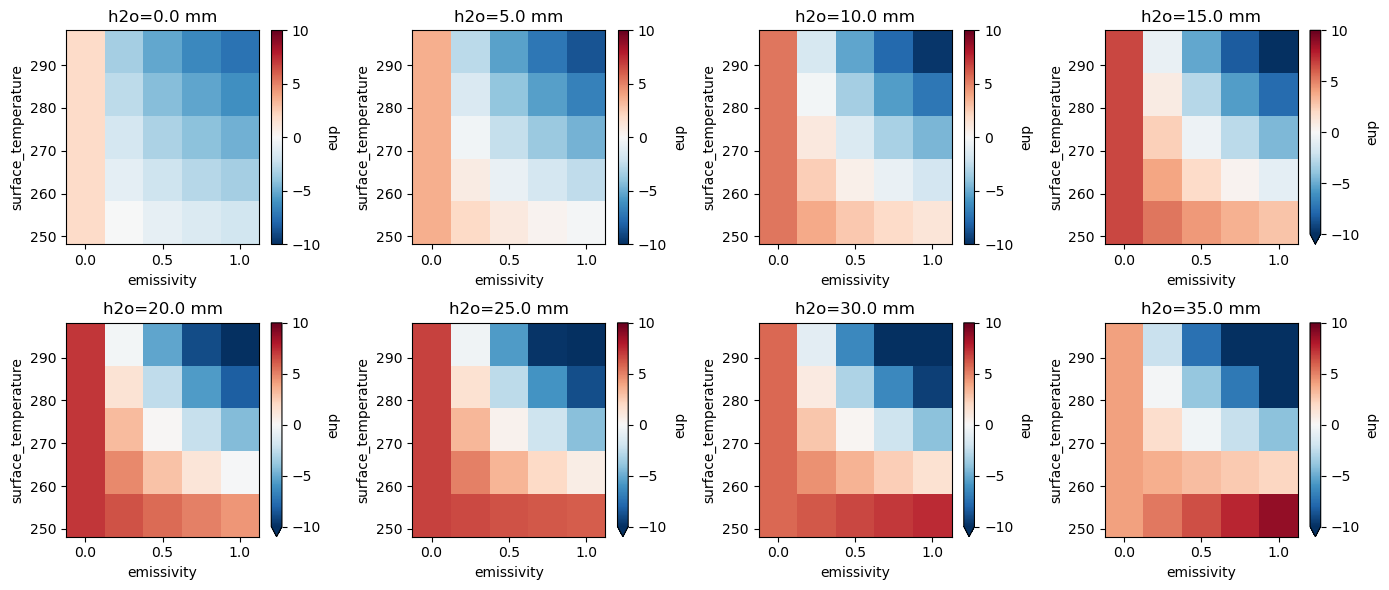

In [7]:
ds_out_TOA = ds_out.sel(altitude=100)
ds_out_SUR = ds_out.sel(altitude=0)

fig, ax = plt.subplots(2, 4 , figsize=(14, 6))
ax = ax.flatten()

for i, h20_val in enumerate(h20_values):
    ds_subset = ds_out.sel(h2o_column=h20_val)
    delta_atm = ds_subset.sel(altitude=100) - ds_subset.sel(altitude=0)
    delta_atm['emissivity'] = 1 - delta_atm['albedo']
    delta_atm = delta_atm.swap_dims({'albedo': 'emissivity'})

    delta_atm.eup.plot(ax=ax[i], vmin=-10, vmax=10, cmap='RdBu_r', x='emissivity')
    ax[i].set_title(f"h2o={h20_val:.1f} mm")
plt.tight_layout()